In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Helvetica"
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
merged_df = pd.read_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Thesis-Work/RSV-Sequencing/qPCR/Files_python/022826-qPCR-NMH-and-LCH-use.csv")

In [3]:
#Loading only NMH Dataset
NMH = merged_df[merged_df['type'] == 'NMH']

In [9]:
#Dropping rows that have an undetermined CT
NMH = NMH[~NMH['CT'].str.contains('undetermined')]
#NMH2 = NMH1.dropna(subset=['clade'])
NMH["CT"] = pd.to_numeric(NMH["CT"])

/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_38753/3828718247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NMH["CT"] = pd.to_numeric(NMH["CT"])


/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_38753/735282075.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ordered = merged_df.groupby('Status').median().sort_values('CT', ascending=False).index
/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_38753/735282075.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ordered = merged_df.groupby('Status').median().sort_values(


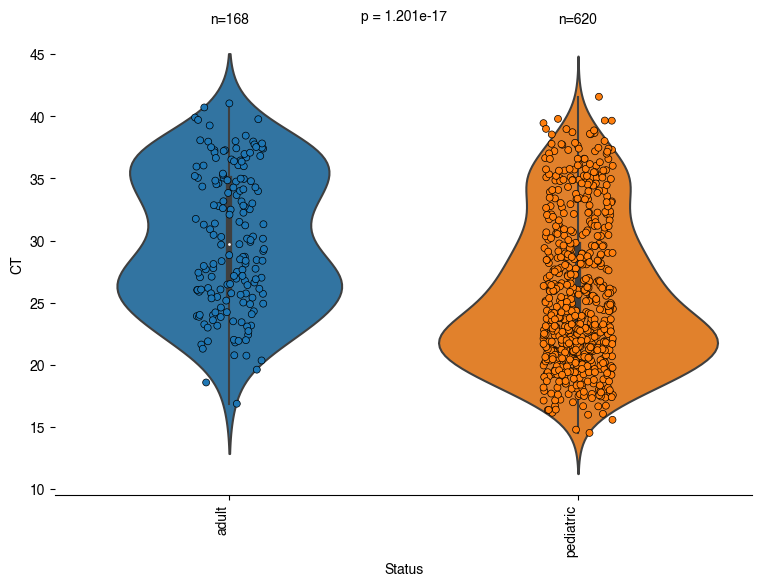

In [33]:
ordered = merged_df.groupby('Status').median().sort_values('CT', ascending=False).index

fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(x='Status', y='CT', data=merged_df, order=ordered)

sns.stripplot(x="Status", 
              y="CT", 
              data=merged_df, 
              jitter=True, 
              ax=ax,  
              edgecolor='black',
              order=ordered,
              linewidth=0.5)

# Add sample size n
counts = merged_df['Status'].value_counts().reindex(ordered)
for i, count in enumerate(counts):
    ax.text(i, ax.get_ylim()[1] + 0.5, f"n={count}", ha='center', va='bottom', fontsize=10)
    
    from scipy.stats import mannwhitneyu
ordered = merged_df.groupby('Status').median().sort_values(
    'CT', ascending=False).index

group1 = merged_df[merged_df['Status'] == ordered[0]]['CT']
group2 = merged_df[merged_df['Status'] == ordered[1]]['CT']

stat, p = mannwhitneyu(group1, group2)

ax.text(0.5, ax.get_ylim()[1] + 1, f"p = {p:.3e}", ha='center')


_ = plt.xticks(rotation=90, ha='right')
sns.despine(left=True)
#plt.savefig("030126-CT-comparison-total.pdf", format="pdf", bbox_inches="tight")

In [25]:
merged_df = merged_df[~merged_df['CT'].astype(str).str.contains('undetermined', case=False, na=False)]
merged_df["CT"] = pd.to_numeric(merged_df["CT"])

/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_38753/1972693772.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df["CT"] = pd.to_numeric(merged_df["CT"])


In [29]:
from scipy.stats import mannwhitneyu
ordered = merged_df.groupby('Status').median().sort_values(
    'CT', ascending=False).index

group1 = merged_df[merged_df['Status'] == ordered[0]]['CT']
group2 = merged_df[merged_df['Status'] == ordered[1]]['CT']

stat, p = mannwhitneyu(group1, group2)

ax.text(0.5, ax.get_ylim()[1] + 1, f"p = {p:.3e}", ha='center')

/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_38753/3383211245.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ordered = merged_df.groupby('Status').median().sort_values(


Text(0.5, 47.722300427825225, 'p = 1.201e-17')

F-statistic: 3.9516303438318072
P-value: 9.365286104823066e-05


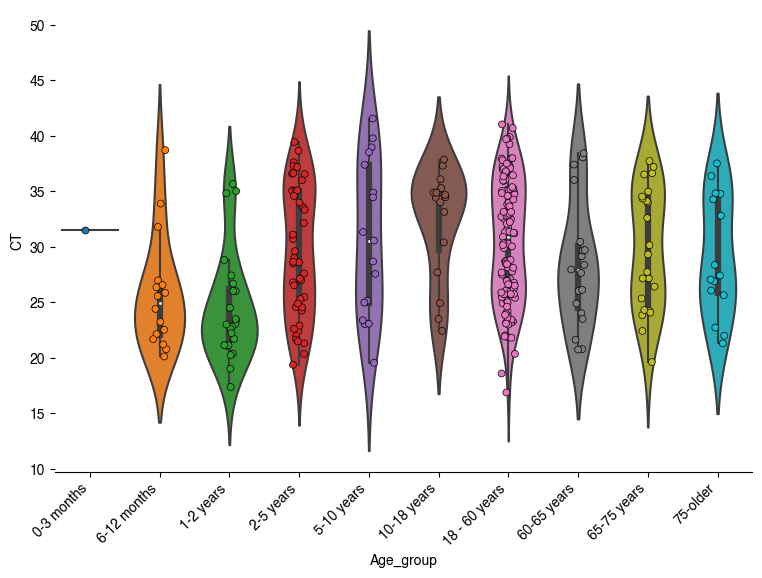

In [11]:
#ordered = NMH.groupby('Age_group').median().sort_values(
#'CT', ascending=False).index

from scipy import stats

# Extract each condition into separate arrays
groups = [
    group["CT"].values
    for name, group in NMH.groupby("Age_group")
]

# Run ANOVA
f_statistic, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

age_group = ['0-3 months', '6-12 months', '1-2 years', '2-5 years',
       '5-10 years', '10-18 years', '18 - 60 years', '60-65 years',
       '65-75 years', '75-older']

fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(x='Age_group', y='CT', data=NMH,
               order=age_group)


sns.stripplot(x="Age_group", 
              y="CT", 
              data=NMH, 
              jitter=True, 
              ax=ax,  
              edgecolor='black',
              order=age_group,
              linewidth=0.5)


_ = plt.xticks(rotation=45, ha='right')
sns.despine(left=True)


# Perform a t-test or any other significance test
#t_statistic, p_value = stats.ttest_ind(group_a_data, group_b_data)

# Define your significance threshold (e.g., 0.05)
#alpha = 0.05

# Add significance asterisks if p-value is below the threshold
#if p_value < alpha:
#    ax.annotate("*", xy=(0, max(final["CT"])), xytext=(0.5, max(final["CT"]) + 1),
#                fontsize=12, ha="center", va="center", color='red')


In [21]:
merged_df['Age_group']

0       0-3 months
1      6-12 months
2      6-12 months
3      6-12 months
4      6-12 months
          ...     
285       75-older
286       75-older
287       75-older
288       75-older
289       75-older
Name: Age_group, Length: 288, dtype: object

# Matching LCH values to add 

In [27]:
merged_df

,Sample Name,CT,subtype,Date,dob,sample_date,Age,Age_months,Age_group,Season,Status,type
0,RSV687,31.547,B,1/30/24,09/11/2023,12/6/2023,0.0,2.0,0-3 months,2023-2024,pediatric,NMH
1,RSV658,25.557,A,1/31/24,03/30/2023,11/27/2023,0.0,7.0,6-12 months,2023-2024,pediatric,NMH
2,RSV808,22.52083573,B,11/25/24,06/20/2023,1/23/2024,0.0,7.0,6-12 months,2023-2024,pediatric,NMH
3,RSV626,20.77538523,B,2/1/24,02/06/2023,11/1/2023,0.0,8.0,6-12 months,2023-2024,pediatric,NMH
4,RSV650,21.2,B,1/31/24,03/14/2023,11/22/2023,0.0,8.0,6-12 months,2023-2024,pediatric,NMH
...,...,...,...,...,...,...,...,...,...,...,...,...
898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
#Dropping rows that have an undetermined CT
merged_df = merged_df.dropna(how='all')
merged_df = merged_df[~merged_df['CT'].str.contains('undetermined')]
#merged_df2 = merged_df1.dropna(subset=['clade'])
merged_df["CT"] = pd.to_numeric(merged_df["CT"])

F-statistic: 13.71140615969594
P-value: 3.1169836419846654e-24


TypeError: 'Figure' object is not subscriptable

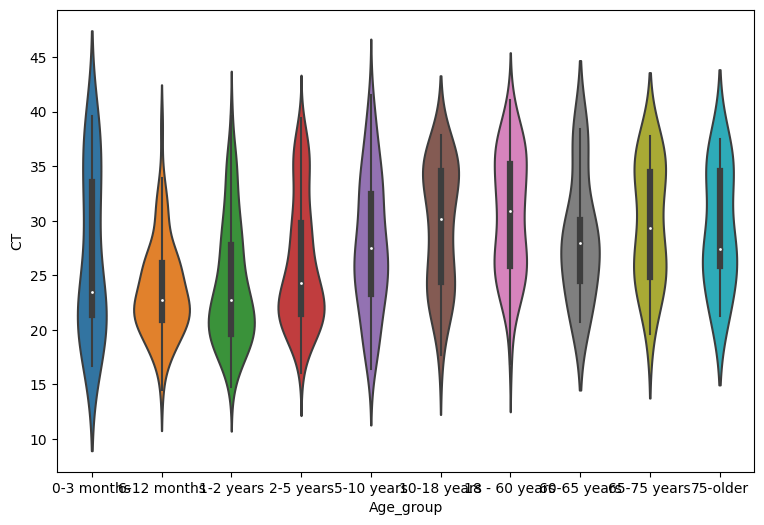

In [54]:
#ordered = merged_df.groupby('Age_group').median().sort_values(
#'CT', ascending=False).index

from scipy import stats

# Extract each condition into separate arrays
groups = [
    group["CT"].values
    for name, group in merged_df.groupby("Age_group")
]

# Run ANOVA
f_statistic, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

age_group = ['0-3 months', '6-12 months', '1-2 years', '2-5 years',
       '5-10 years', '10-18 years', '18 - 60 years', '60-65 years',
       '65-75 years', '75-older']

fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(x='Age_group', y='CT', data=merged_df,
               order=age_group, showmedians=True)


sns.stripplot(x="Age_group", 
              y="CT", 
              data=merged_df, 
              jitter=True, 
              ax=ax,  
              edgecolor='black',
              order=age_group,
              linewidth=0.5)


_ = plt.xticks(rotation=45, ha='right')
sns.despine(left=True)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


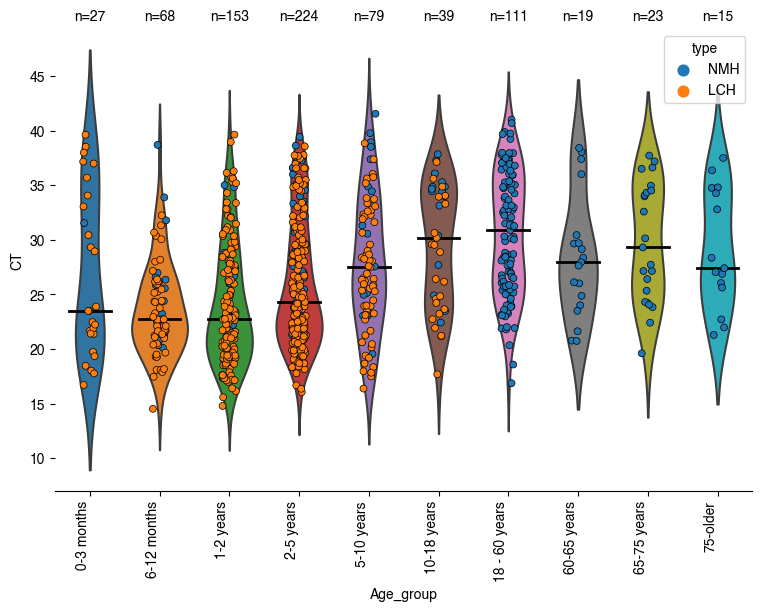

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your age order
age_group = ['0-3 months', '6-12 months', '1-2 years', '2-5 years',
             '5-10 years', '10-18 years', '18 - 60 years', '60-65 years',
             '65-75 years', '75-older']

fig, ax = plt.subplots(figsize=(9, 6))

# Draw the violinplot
sns.violinplot(x='Age_group', y='CT', data=merged_df,
               order=age_group, inner=None, ax=ax)  # inner=None hides default bars

# Draw the median line manually
medians = merged_df.groupby('Age_group')['CT'].median().reindex(age_group)

for i, median in enumerate(medians):
    ax.plot([i - 0.3, i + 0.3], [median, median], color='black', linewidth=2)

# Optional: overlay stripplot
sns.stripplot(x="Age_group", 
              y="CT", 
              data=merged_df, 
              jitter=True, 
              ax=ax,  
              edgecolor='black',
              order=age_group,
              hue="type",
              linewidth=0.5)

# Add sample size n
counts = merged_df['Age_group'].value_counts().reindex(age_group)
for i, count in enumerate(counts):
    ax.text(i, ax.get_ylim()[1] + 0.5, f"n={count}", ha='center', va='bottom', fontsize=10)


plt.xticks(rotation=90, ha='right')
sns.despine(left=True)
plt.savefig("030126-CT-comparison.pdf", format="pdf", bbox_inches="tight")

In [37]:
import itertools
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

ordered = ['0-3 months', '6-12 months', '1-2 years', '2-5 years',
       '5-10 years', '10-18 years', '18 - 60 years', '60-65 years',
       '65-75 years', '75-older']

# Convert to list in case `ordered` is a Pandas Index
ordered_list = list(ordered)

pairs = list(itertools.combinations(ordered_list, 2))
results = []

# Compute raw p-values safely
for a, b in pairs:
    g1 = NMH.loc[NMH['Age_group'] == a, 'CT'].dropna().astype(float)
    g2 = NMH.loc[NMH['Age_group'] == b, 'CT'].dropna().astype(float)

    # Skip if either group is empty
    if len(g1) == 0 or len(g2) == 0:
        print(f"Skipping pair {a} vs {b} because one group is empty.")
        continue

    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    results.append([a, b, stat, p])

# Convert to DataFrame
df_stats = pd.DataFrame(results, columns=['group1', 'group2', 'statistic', 'p_raw'])

# Adjust p-values (FDR Benjamini–Hochberg)
df_stats['p_adj'] = multipletests(df_stats['p_raw'], method='fdr_bh')[1]

# Add significance stars
def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

df_stats['significance'] = df_stats['p_adj'].apply(stars)

df_stats

,group1,group2,statistic,p_raw,p_adj,significance
0,0-3 months,6-12 months,13.0,0.470588,0.775862,ns
1,0-3 months,1-2 years,21.0,0.320000,0.685714,ns
2,0-3 months,2-5 years,27.0,0.851064,0.952381,ns
3,0-3 months,5-10 years,10.0,0.888889,0.952381,ns
4,0-3 months,10-18 years,5.0,0.705882,0.907563,ns
5,0-3 months,18 - 60 years,61.0,0.910714,0.953073,ns
6,0-3 months,60-65 years,15.0,0.500000,0.775862,ns
7,0-3 months,65-75 years,13.0,0.885110,0.952381,ns
8,0-3 months,75-older,9.0,0.875000,0.952381,ns
9,6-12 months,1-2 years,218.0,0.481432,0.775862,ns


In [39]:
import itertools
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

ordered = ['0-3 months', '6-12 months', '1-2 years', '2-5 years',
       '5-10 years', '10-18 years', '18 - 60 years', '60-65 years',
       '65-75 years', '75-older']

# Convert to list in case `ordered` is a Pandas Index
ordered_list = list(ordered)

pairs = list(itertools.combinations(ordered_list, 2))
results = []

# Compute raw p-values safely
for a, b in pairs:
    g1 = merged_df.loc[merged_df['Age_group'] == a, 'CT'].dropna().astype(float)
    g2 = merged_df.loc[merged_df['Age_group'] == b, 'CT'].dropna().astype(float)

    # Skip if either group is empty
    if len(g1) == 0 or len(g2) == 0:
        print(f"Skipping pair {a} vs {b} because one group is empty.")
        continue

    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    results.append([a, b, stat, p])

# Convert to DataFrame
df_stats = pd.DataFrame(results, columns=['group1', 'group2', 'statistic', 'p_raw'])

# Adjust p-values (FDR Benjamini–Hochberg)
df_stats['p_adj'] = multipletests(df_stats['p_raw'], method='fdr_bh')[1]

# Add significance stars
def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

df_stats['significance'] = df_stats['p_adj'].apply(stars)

df_stats

,group1,group2,statistic,p_raw,p_adj,significance
0,0-3 months,6-12 months,1094.0,1.475917e-01,2.439017e-01,ns
1,0-3 months,1-2 years,2471.0,1.047011e-01,1.884620e-01,ns
2,0-3 months,2-5 years,3100.5,8.311285e-01,8.819179e-01,ns
3,0-3 months,5-10 years,945.0,3.802792e-01,5.107017e-01,ns
4,0-3 months,10-18 years,401.0,1.030528e-01,1.884620e-01,ns
5,0-3 months,18 - 60 years,1028.0,1.165114e-02,2.746157e-02,*
6,0-3 months,60-65 years,211.0,3.154212e-01,4.578694e-01,ns
7,0-3 months,65-75 years,223.0,9.035721e-02,1.767858e-01,ns
8,0-3 months,75-older,159.0,2.590038e-01,3.885057e-01,ns
9,6-12 months,1-2 years,5226.0,9.572816e-01,9.572816e-01,ns


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


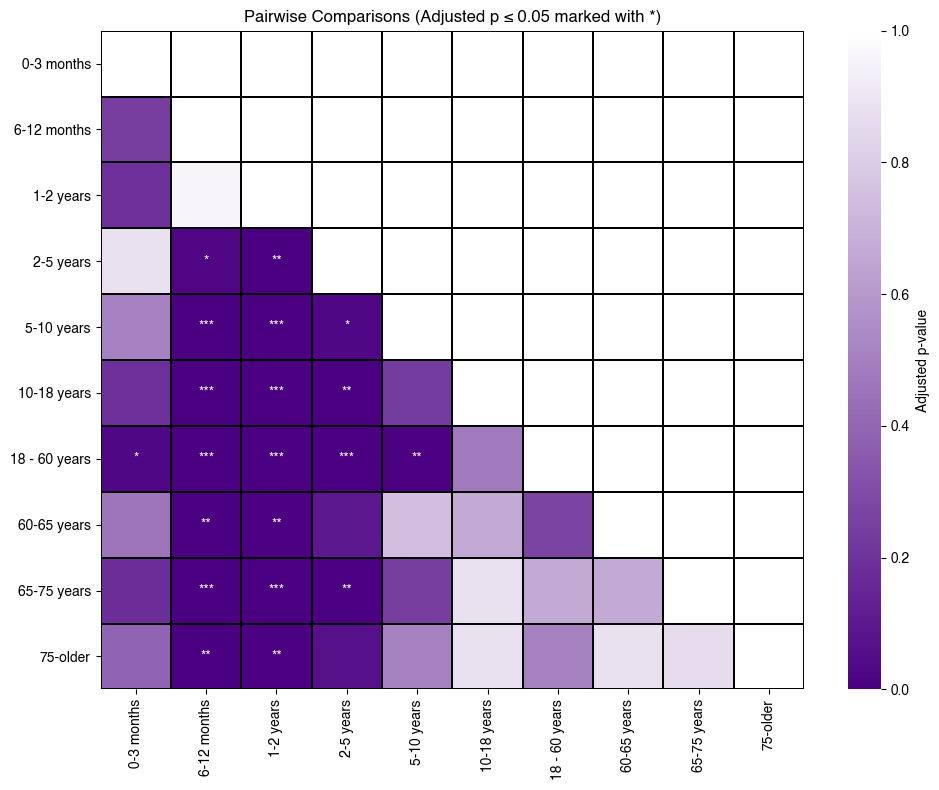

In [59]:
#Defining the age group used for stratification
age_group = [
    '0-3 months', '6-12 months', '1-2 years', '2-5 years',
    '5-10 years', '10-18 years', '18 - 60 years',
    '60-65 years', '65-75 years', '75-older'
]

#adding different groups
df_stats['group1'] = pd.Categorical(df_stats['group1'], categories=age_group, ordered=True)
df_stats['group2'] = pd.Categorical(df_stats['group2'], categories=age_group, ordered=True)

#Creating a matrix
matrix = pd.DataFrame(np.nan, index=age_group, columns=age_group)

# Fill symmetric matrix with adjusted p-values
for _, row in df_stats.iterrows():
    g1, g2, p = row['group1'], row['group2'], row['p_adj']
    matrix.loc[g1, g2] = p
    matrix.loc[g2, g1] = p
    

#Making a color schema
purple_white = LinearSegmentedColormap.from_list(
    "purple_white",
    ["#4B0082", "#FFFFFF"]   # Dark purple → white
)


#Annotating p-value significance on the figure
annot_matrix = matrix.copy()

for i in matrix.index:
    for j in matrix.columns:
        if pd.notna(matrix.loc[i, j]):
            p = matrix.loc[i, j]
            if p < 0.001:
                annot_matrix.loc[i, j] = '***'
            elif p < 0.01:
                annot_matrix.loc[i, j] = '**'
            elif p < 0.05:
                annot_matrix.loc[i, j] = '*'
            else:
                annot_matrix.loc[i, j] = ''

#Eliminate the upper triangel that is present when mapping out p-values
mask = np.triu(np.ones_like(matrix, dtype=bool))

#plot p values on heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    matrix,
    mask=mask,
    cmap=purple_white,      # small p-values = darker
    vmin=0,
    vmax=1,
    annot=annot_matrix,
    fmt='',
    linewidths=.003, 
    linecolor='black',
    cbar_kws={'label': 'Adjusted p-value'}
)

plt.title("Pairwise Comparisons (Adjusted p ≤ 0.05 marked with *)")
plt.tight_layout()
plt.savefig("030126-pariwise-comparison.pdf", format="pdf", bbox_inches="tight")